In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [54]:
df = pd.read_csv("Road Accident Data.csv")
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [55]:
df.shape

(307973, 21)

In [56]:
df.isnull().sum()

,0
Accident_Index,0
Accident Date,0
Day_of_Week,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,0
Latitude,0
Light_Conditions,0
Local_Authority_(District),0
Carriageway_Hazards,302549


In [57]:
df.drop([
    "Accident_Index",
    "Local_Authority_(District)"
], axis=1, inplace=True)

In [58]:
df["Accident Date"] = pd.to_datetime(df["Accident Date"])

df["Year"] = df["Accident Date"].dt.year
df["Month"] = df["Accident Date"].dt.month
df["Day"] = df["Accident Date"].dt.day

df["Time"] = pd.to_datetime(df["Time"], errors='coerce')
df["Hour"] = df["Time"].dt.hour

df.drop(["Accident Date", "Time"], axis=1, inplace=True)

/tmp/ipykernel_1754/971339430.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"], errors='coerce')


In [59]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1754/3563149562.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1754/3563149562.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [65]:
df["Accident_Severity"] = df["Accident_Severity"].replace({
    "Fetal": "Fatal"
})

In [66]:
print(df["Accident_Severity"].unique())

['Serious' 'Slight' 'Fatal']


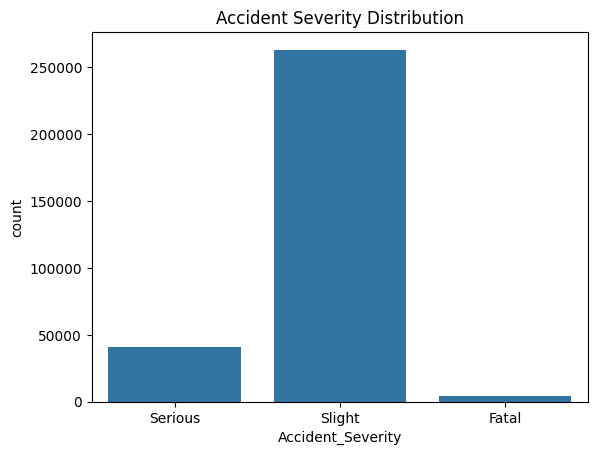

In [68]:
sns.countplot(x=df["Accident_Severity"])
plt.title("Accident Severity Distribution")
plt.show()

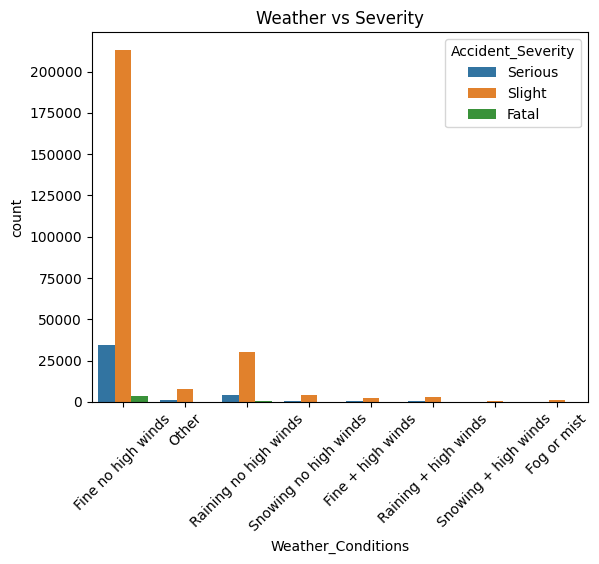

In [69]:
sns.countplot(x=df["Weather_Conditions"], hue=df["Accident_Severity"])
plt.xticks(rotation=45)
plt.title("Weather vs Severity")
plt.show()

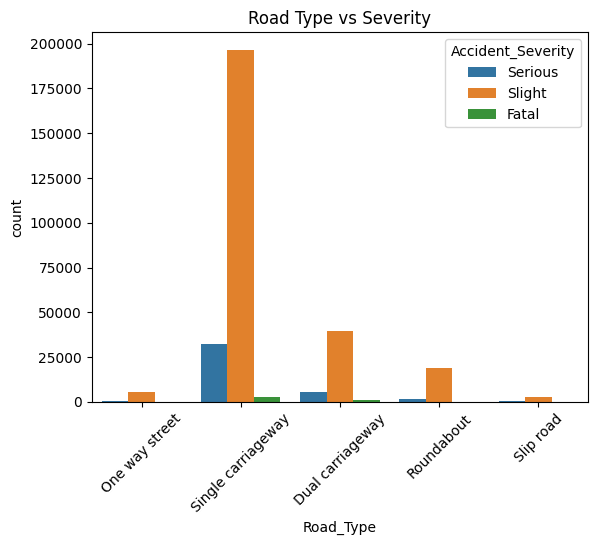

In [70]:
sns.countplot(x=df["Road_Type"], hue=df["Accident_Severity"])
plt.xticks(rotation=45)
plt.title("Road Type vs Severity")
plt.show()

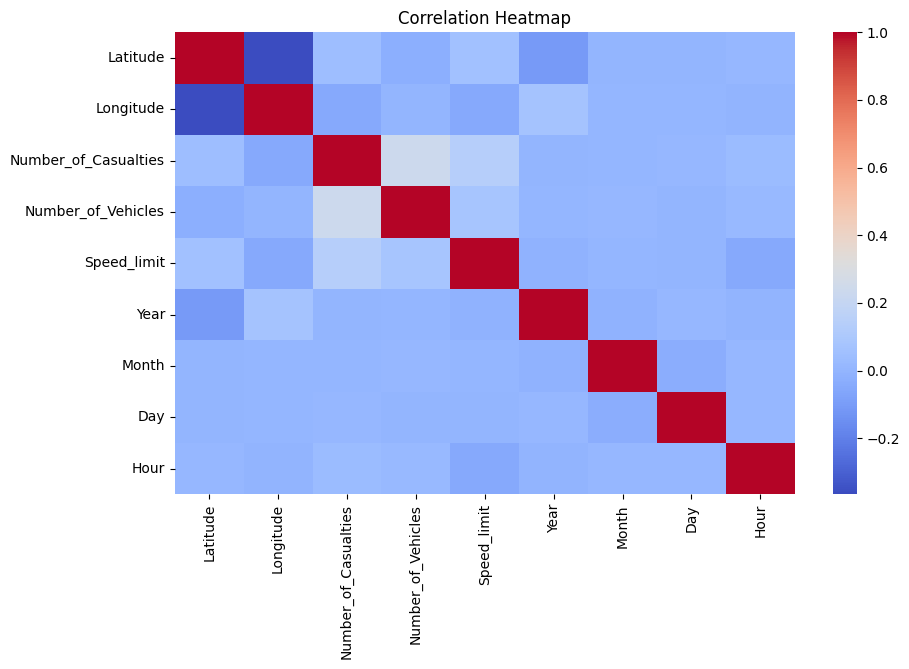

In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [73]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [75]:
X = df.drop("Accident_Severity", axis=1)
y = df["Accident_Severity"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())

Before SMOTE:
Accident_Severity
2    210617
1     32639
0      3122
Name: count, dtype: int64

After SMOTE:
Accident_Severity
2    210617
1    210617
0    210617
Name: count, dtype: int64


In [89]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [90]:
pred_lr = lr.predict(X_test)

In [91]:
dt = DecisionTreeClassifier()
dt.fit(X_train_res, y_train_res)


DecisionTreeClassifier()

In [92]:
pred_dt = dt.predict(X_test)

In [93]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)


RandomForestClassifier(random_state=42)

In [94]:
pred_rf = rf.predict(X_test)

In [100]:
print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Decision Tree:", accuracy_score(y_test, pred_dt))
print("Random Forest:", accuracy_score(y_test, pred_rf))

print("\nClassification Report \n")
print(classification_report(y_test, pred_rf))

Logistic Regression: 0.8548908190599886
Decision Tree: 0.7427713288416268
Random Forest: 0.8543712963714587

Classification Report 

              precision    recall  f1-score   support

           0       0.50      0.00      0.00       831
           1       0.37      0.01      0.02      8101
           2       0.86      1.00      0.92     52663

    accuracy                           0.85     61595
   macro avg       0.57      0.34      0.31     61595
weighted avg       0.79      0.85      0.79     61595



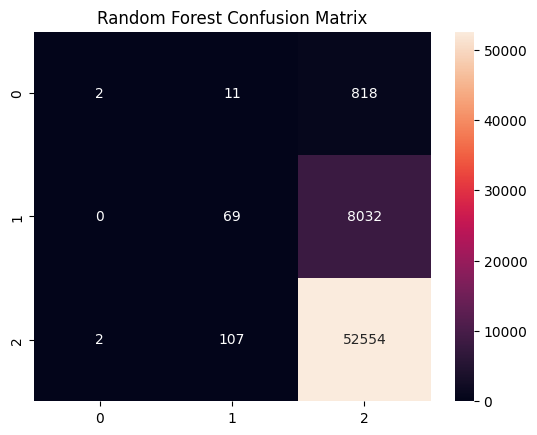

In [96]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

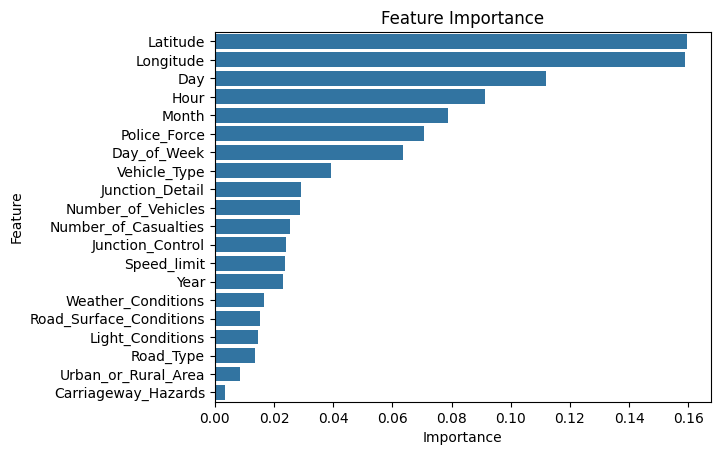

In [97]:
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": df.drop("Accident_Severity", axis=1).columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()